In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print(df.info())

print("\nClass Distribution:")
print(df['species'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (150, 4)
Labels Shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [ ]:
k_values = range(1, 16)

accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    score = accuracy_score(y_test, predictions)
    accuracy_scores.append(score)

    print(f"K = {k} --> Accuracy = {score:.4f}")

K = 1 --> Accuracy = 0.9667
K = 2 --> Accuracy = 0.9333
K = 3 --> Accuracy = 0.9333
K = 4 --> Accuracy = 0.9333
K = 5 --> Accuracy = 0.9333
K = 6 --> Accuracy = 0.9333
K = 7 --> Accuracy = 0.9667
K = 8 --> Accuracy = 0.9333
K = 9 --> Accuracy = 0.9667
K = 10 --> Accuracy = 0.9667
K = 11 --> Accuracy = 0.9667
K = 12 --> Accuracy = 0.9667
K = 13 --> Accuracy = 0.9667
K = 14 --> Accuracy = 0.9333
K = 15 --> Accuracy = 0.9667


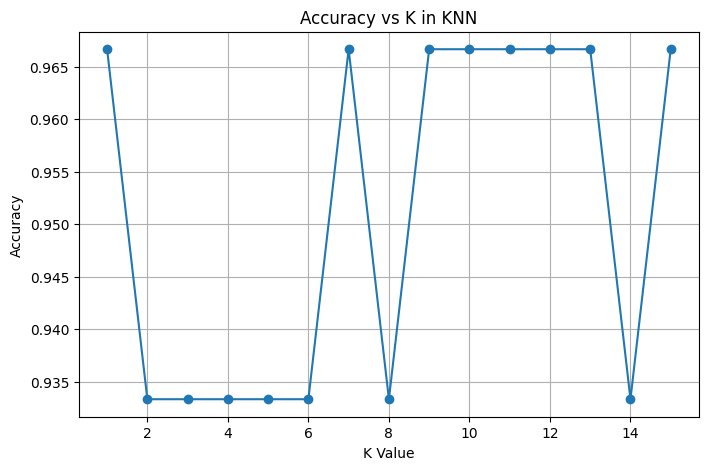

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracy_scores,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K in KNN")

plt.grid(True)
plt.show()

In [ ]:
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 1
Best Accuracy: 0.9666666666666667


In [ ]:
final_model = KNeighborsClassifier(n_neighbors=best_k)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Final Accuracy:")
print(accuracy_score(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Final Accuracy:
0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

